In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import re

In [ ]:
base_dir = Path("/content/drive/MyDrive/ais") # adjust

mistral_zero = pd.read_csv(base_dir / "mistral_zero.csv")
mistral_few  = pd.read_csv(base_dir / "mistral_few.csv")
phi_few      = pd.read_csv(base_dir / "phi_few.csv")
phi_zero     = pd.read_csv(base_dir / "phi_zero.csv")
gemma_zero   = pd.read_csv(base_dir / "gemma_zero.csv")
gemma_few    = pd.read_csv(base_dir / "gemma_few.csv")
gpt_zero     = pd.read_csv(base_dir / "gpt_zero.csv")
gpt_few     = pd.read_csv(base_dir / "gpt_few.csv")


In [ ]:
dfs = {
    "gemma_zero_shot": gemma_zero,
    "gemma_few_shot": gemma_few,
    "phi_zero_shot": phi_zero,
    "phi_few_shot": phi_few,
    "mistral_zero_shot": mistral_zero,
    "mistral_few_shot": mistral_few,
    "gpt4_zero_shot": gpt_zero,
    "gpt4_few_shot": gpt_few


}

# Compute averages for numerical columns
summary = pd.DataFrame()

for name, df in dfs.items():
    numeric_cols = df.select_dtypes(include='number')
    summary[name] = numeric_cols.mean()

# Optional: transpose so each model is a row
summary = summary.transpose()

print(summary)

                   elapsed_s  input_tokens  output_tokens  total_tokens  \
gemma_zero_shot    24.068394        974.84          76.92       1051.76   
gemma_few_shot     17.869231       1257.84         105.94       1363.78   
phi_zero_shot      11.328420       1074.52         147.51       1222.03   
phi_few_shot       14.804070       1388.52         121.03       1509.55   
mistral_zero_shot  18.522571       1063.50         108.49       1171.99   
mistral_few_shot   19.512921       1365.50         123.12       1488.62   
gpt4_zero_shot      1.310640        856.50          58.00        914.50   
gpt4_few_shot       1.125996       1071.50          61.49       1132.99   

                   avg_power_w  energy_joules  energy_wh    rouge1    rouge2  \
gemma_zero_shot      34.441024     828.054457   0.230015  0.124693  0.012772   
gemma_few_shot       33.776720     603.672733   0.167687  0.145525  0.023653   
phi_zero_shot        56.760206     644.701013   0.179084  0.110117  0.020902   
phi_

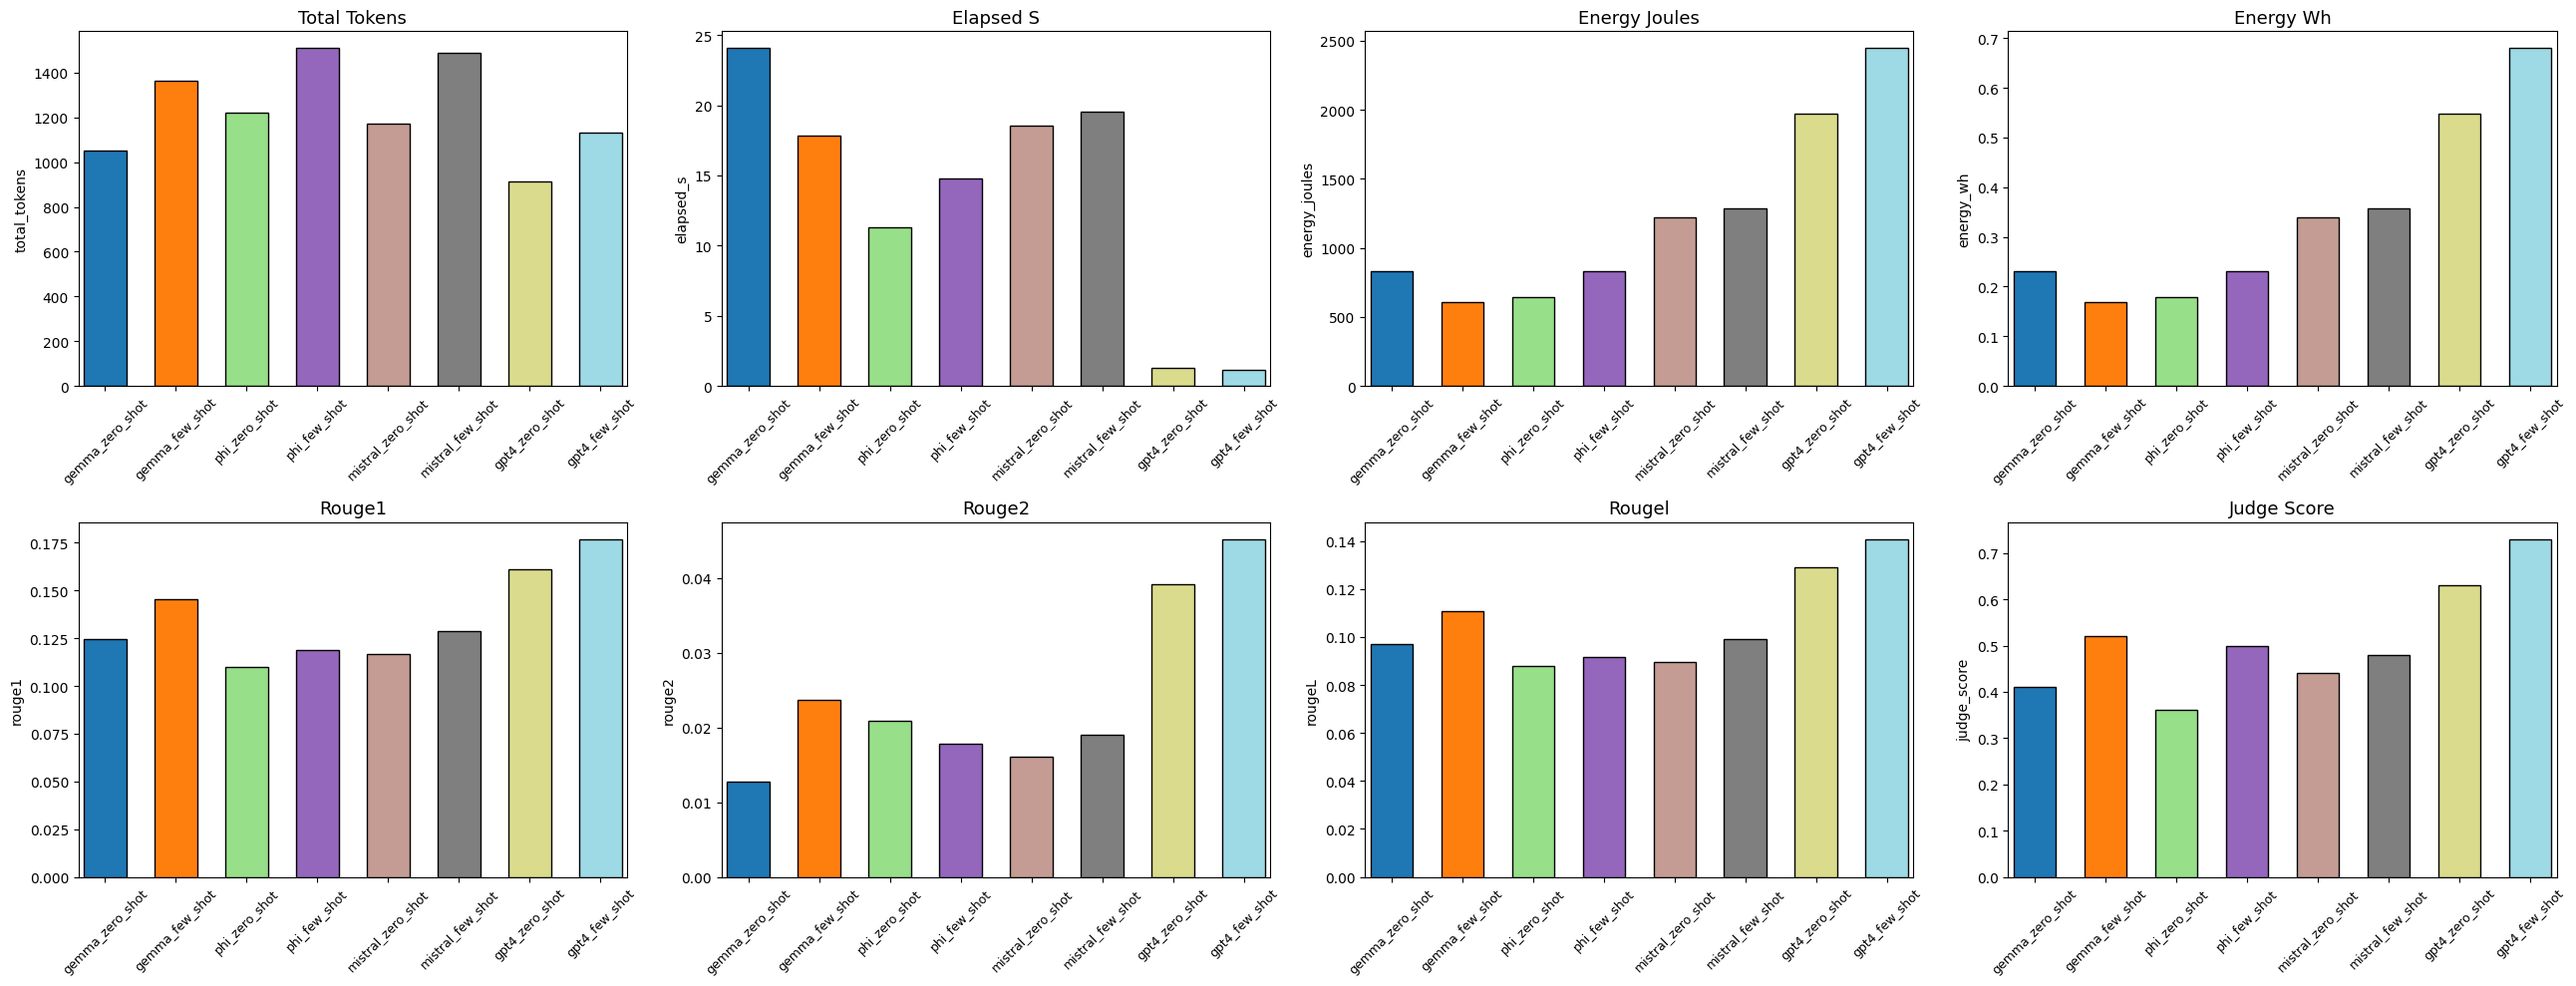

In [ ]:
# List of 8 metrics → will be arranged into 2 rows × 4 columns
metrics = [
    'total_tokens', 'elapsed_s', 'energy_joules', 'energy_wh',
    'rouge1', 'rouge2', 'rougeL', 'judge_score'
]

models = summary.index.tolist()

# Colors for each model
colors = plt.cm.tab20(np.linspace(0, 1, len(models)))

# 2×4 subplot grid
fig, axes = plt.subplots(2, 4, figsize=(26, 10))

# Flatten axes array for easy looping
axes = axes.flatten()

for i, metric in enumerate(metrics):
    ax = axes[i]
    values = summary[metric].values

    ax.bar(
        models,
        values,
        color=colors,
        width=0.6,
        edgecolor='black'
    )

    ax.set_title(metric.replace('_', ' ').title(), fontsize=13)
    ax.tick_params(axis='x', rotation=45, labelsize=9)
    ax.set_ylabel(metric)
    ax.margins(x=0.01)   # reduce whitespace

plt.tight_layout()
plt.show()


In [ ]:
def _darken(rgb, factor=0.7):
    """Darken an RGB tuple by multiplying each channel."""
    return tuple(max(0, min(1, c * factor)) for c in rgb)

def _infer_base_and_shot(name):
    """
    From keys like 'phi_zero_shot', 'phi_few_shot', 'gemma_zero_shot2', etc.
    returns (base_model, shot_type) where shot_type in {'zero','few','other'}.
    """
    lower = name.lower()
    base = lower.split("_")[0]  # phi/gemma/mistral/gpt/...
    if "_zero" in lower:
        shot = "zero"
    elif "_few" in lower:
        shot = "few"
    else:
        shot = "other"
    return base, shot

def plot_avg_by_type_2x3(
    dfs,
    y_col="judge_score",          # <-- pass "rougeL" to plot ROUGE-L
    type_col="type",
    figsize=(18, 10),
    base_palette=None,            # optional dict: {"phi": (r,g,b), ...}
    few_darken_factor=0.7         # few-shot bars darker
):
    """
    For each df in dfs:
      - group by type_col
      - compute mean of y_col
    Then plot 2x3 subplots (one per type).
      - x-axis per subplot: dataset keys (models/prompts)
      - y-axis: avg of y_col

    Colors:
      - same base model => same base color
      - few-shot variant => darker shade of base color
    Returns summary table (types x datasets).
    """

    # ---- compute per-df means by type ----
    per_df = {}
    all_types = set()

    for name, df in dfs.items():
        if type_col not in df.columns:
            raise KeyError(f"'{type_col}' not found in df: {name}")
        if y_col not in df.columns:
            raise KeyError(f"'{y_col}' not found in df: {name}")

        means = df.groupby(type_col)[y_col].mean()
        per_df[name] = means
        all_types.update(means.index.tolist())

    all_types = sorted(list(all_types))
    dataset_names = list(per_df.keys())

    # ---- build summary matrix: rows=types, cols=datasets ----
    values = np.full((len(all_types), len(dataset_names)), np.nan, dtype=float)

    for j, dname in enumerate(dataset_names):
        means = per_df[dname]
        for i, t in enumerate(all_types):
            values[i, j] = float(means.get(t, np.nan))

    summary_table = pd.DataFrame(values, index=all_types, columns=dataset_names)

    # ---- color setup: base model colors + darker for few-shot ----
    if base_palette is None:
        # nice distinct bases
        base_palette = {
            "phi":     (0.20, 0.70, 0.20),  # green
            "gemma":   (0.10, 0.55, 0.90),  # blue
            "mistral": (0.95, 0.55, 0.15),  # orange
            "gpt":     (0.60, 0.35, 0.95),  # purple
        }

    colors = []
    for dname in dataset_names:
        base, shot = _infer_base_and_shot(dname)
        base_color = base_palette.get(base, (0.5, 0.5, 0.5))  # fallback gray

        if shot == "few":
            colors.append(_darken(base_color, factor=few_darken_factor))
        else:
            colors.append(base_color)

    # ---- plot 2x3 subplots ----
    fig, axes = plt.subplots(2, 3, figsize=figsize)
    axes = axes.flatten()

    for i, t in enumerate(all_types):
        ax = axes[i]
        y = summary_table.loc[t].values

        ax.bar(dataset_names, y, color=colors, edgecolor="black")
        ax.set_title(t, fontsize=13)
        ax.tick_params(axis='x', rotation=45, labelsize=9)
        ax.set_ylabel(f"Avg {y_col}")

        # Set sensible y-limits
        if y_col == "judge_score":
            ax.set_ylim(0, 1)
        else:
            ax.set_ylim(0, 1)  # ROUGE scores also in [0,1]

    # Hide any extra axes if < 6 types
    for k in range(len(all_types), len(axes)):
        axes[k].axis("off")

    plt.tight_layout()
    plt.show()

    return summary_table


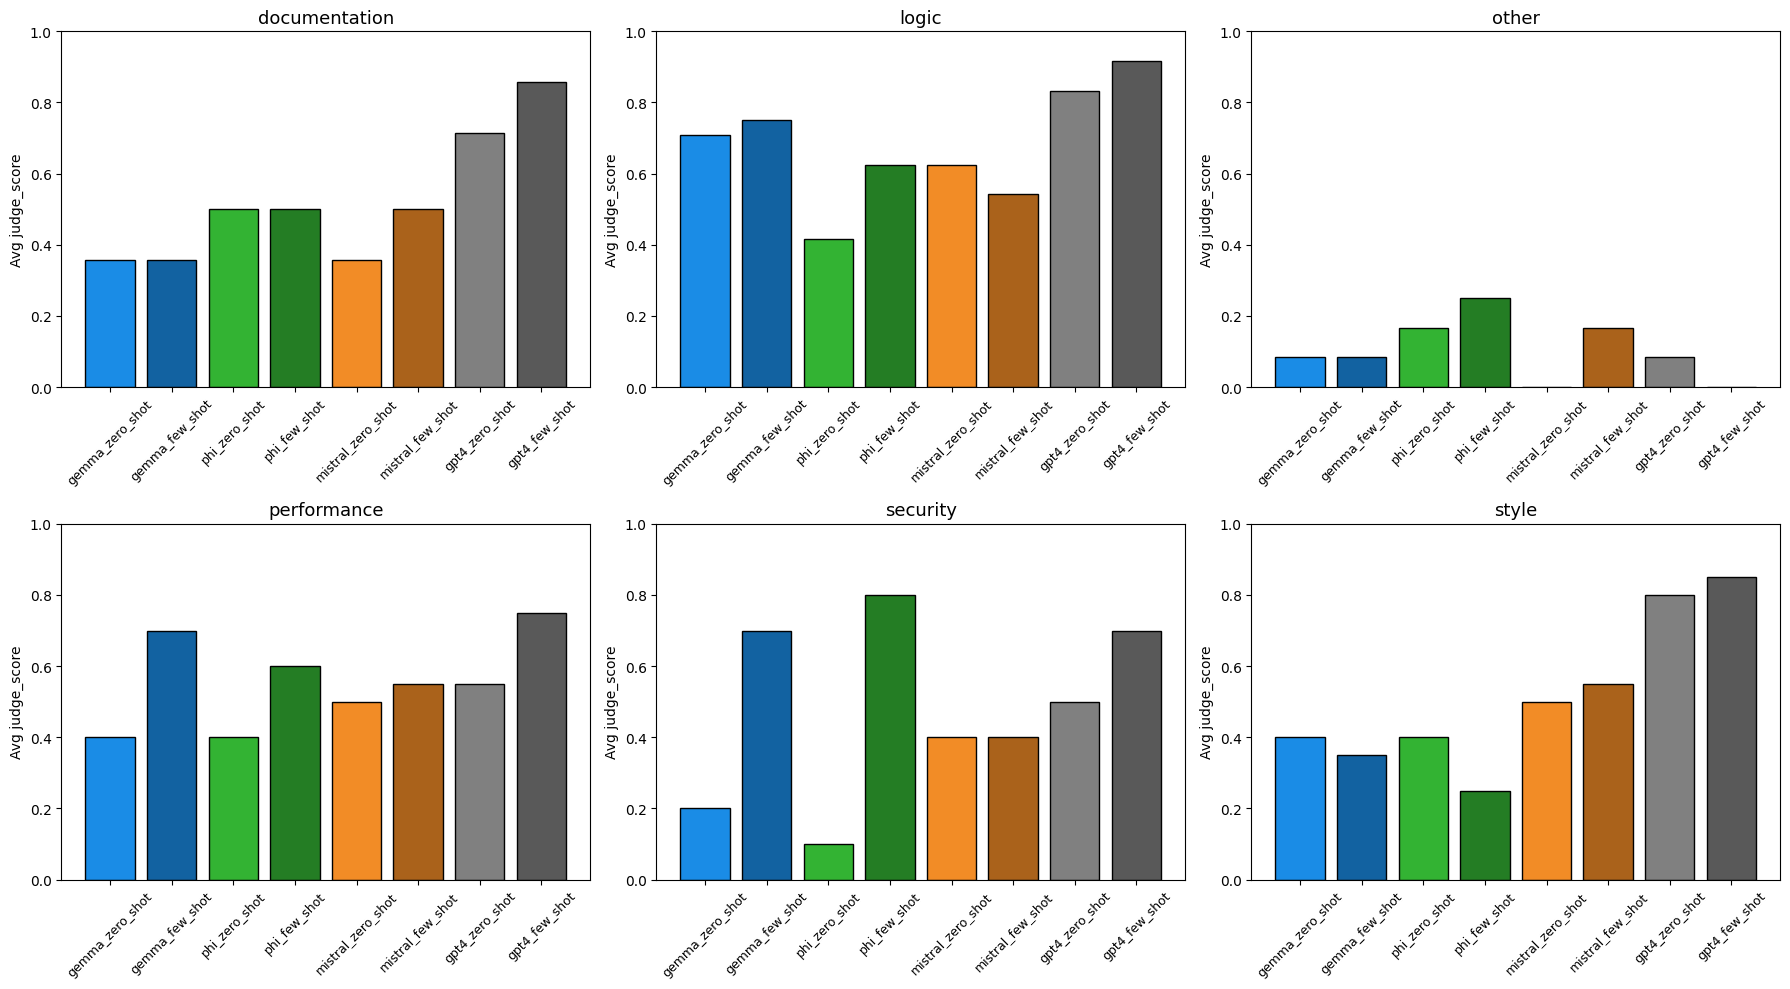

In [ ]:
# Judge score by type (2x3)
judge_by_type = plot_avg_by_type_2x3(dfs, y_col="judge_score")

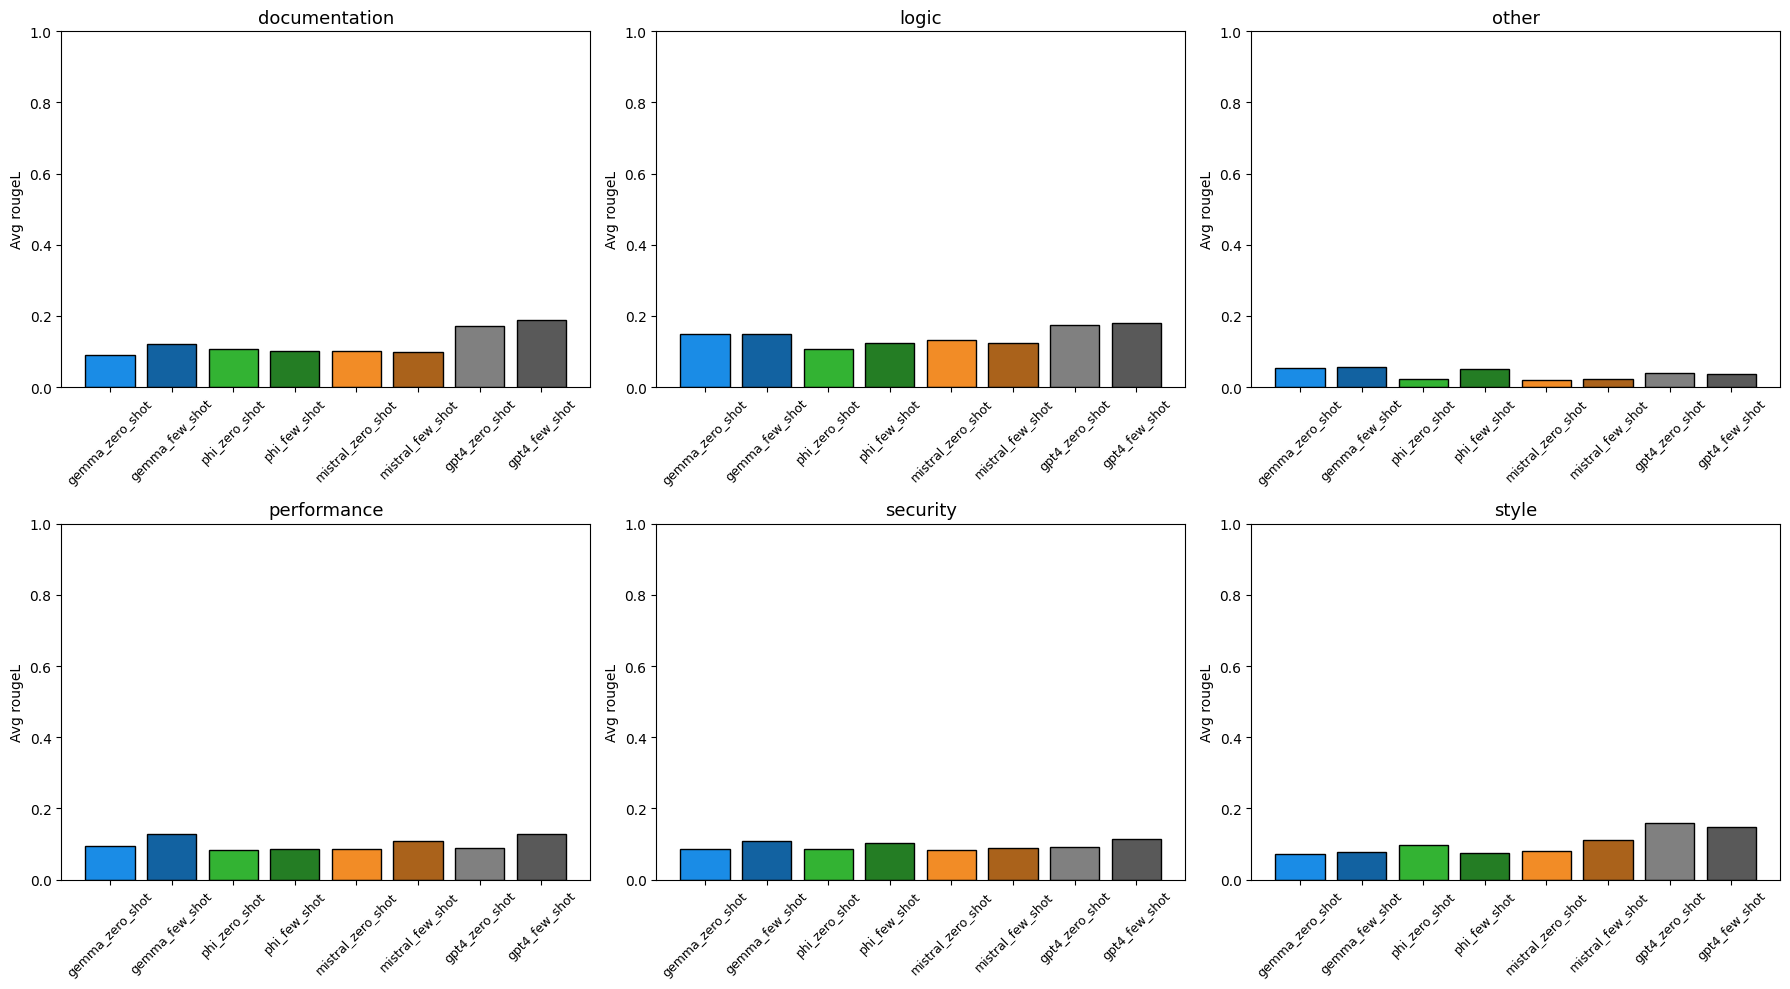

In [ ]:
# ROUGE-L by type (2x3)
rougel_by_type = plot_avg_by_type_2x3(dfs, y_col="rougeL")

In [ ]:
def compare_by_docstr(
    dfs: dict,
    doc_col: str = "has_docstr",
    metrics: tuple = ("judge_score", "rougeL"),
    sort_index: bool = True,
):
    """
    For each df in dfs, compare metrics by has_docstr (True/False).

    Returns:
      summary_tables: dict[name -> pd.DataFrame]  (grouped stats)
      merged_summary: pd.DataFrame               (all models stacked)
    """
    summary_tables = {}
    merged_rows = []

    for name, df in dfs.items():
        if doc_col not in df.columns:
            raise ValueError(f"[{name}] missing column: {doc_col}")

        missing_metrics = [m for m in metrics if m not in df.columns]
        if missing_metrics:
            raise ValueError(f"[{name}] missing metrics: {missing_metrics}")

        # Ensure boolean-ish column
        d = df.copy()
        d[doc_col] = d[doc_col].astype(bool)

        # Grouped stats
        agg_dict = {m: ["count", "mean", "median", "std"] for m in metrics}
        group_stats = d.groupby(doc_col).agg(agg_dict)

        # Flatten multiindex columns like ('judge_score','mean') -> 'judge_score_mean'
        group_stats.columns = [
            f"{col0}_{col1}" for (col0, col1) in group_stats.columns.to_list()
        ]
        if sort_index:
            group_stats = group_stats.sort_index()

        # Add deltas (True - False) for each metric mean/median
        for m in metrics:
            mean_true = group_stats.loc[True, f"{m}_mean"] if True in group_stats.index else float("nan")
            mean_false = group_stats.loc[False, f"{m}_mean"] if False in group_stats.index else float("nan")
            med_true = group_stats.loc[True, f"{m}_median"] if True in group_stats.index else float("nan")
            med_false = group_stats.loc[False, f"{m}_median"] if False in group_stats.index else float("nan")

            group_stats[f"{m}_mean_delta(T-F)"] = mean_true - mean_false
            group_stats[f"{m}_median_delta(T-F)"] = med_true - med_false

        summary_tables[name] = group_stats

        # Also store a stacked version for a single merged table
        stacked = group_stats.reset_index().rename(columns={doc_col: "has_docstr"})
        stacked.insert(0, "df_name", name)
        merged_rows.append(stacked)

    merged_summary = pd.concat(merged_rows, ignore_index=True) if merged_rows else pd.DataFrame()
    return summary_tables, merged_summary


def pretty_print_docstr_comparisons(summary_tables: dict):
    """
    Nicely print each summary table.
    """
    pd.set_option("display.max_colwidth", None)
    pd.set_option("display.max_rows", None)
    pd.set_option("display.max_columns", None)
    pd.set_option("display.expand_frame_repr", False)

    for name, tab in summary_tables.items():
        print("\n" + "="*30)
        print(f"{name}")
        print("="*30)
        print(tab)




In [ ]:
summary_tables, merged_summary = compare_by_docstr(
    dfs,
    doc_col="has_docstr",
    metrics=("judge_score", "rougeL")
)
merged_summary

,df_name,has_docstr,judge_score_count,judge_score_mean,judge_score_median,judge_score_std,rougeL_count,rougeL_mean,rougeL_median,rougeL_std,judge_score_mean_delta(T-F),judge_score_median_delta(T-F),rougeL_mean_delta(T-F),rougeL_median_delta(T-F)
0,gemma_zero_shot,False,80,0.4375,0.0,0.499208,80,0.095597,0.090909,0.071238,-0.1375,0.0,0.006698,0.021789
1,gemma_zero_shot,True,20,0.3000,0.0,0.470162,20,0.102294,0.112698,0.062882,-0.1375,0.0,0.006698,0.021789
2,gemma_few_shot,False,80,0.5375,1.0,0.501737,80,0.110804,0.109091,0.073503,-0.0875,-1.0,0.000557,0.007079
3,gemma_few_shot,True,20,0.4500,0.0,0.510418,20,0.111361,0.116170,0.068845,-0.0875,-1.0,0.000557,0.007079
4,phi_zero_shot,False,80,0.3750,0.0,0.487177,80,0.090582,0.071429,0.085147,-0.0750,0.0,-0.013192,0.001358
5,phi_zero_shot,True,20,0.3000,0.0,0.470162,20,0.077390,0.072787,0.055954,-0.0750,0.0,-0.013192,0.001358
6,phi_few_shot,False,80,0.4875,0.0,0.502997,80,0.095054,0.093023,0.072910,0.0625,1.0,-0.017292,-0.010261
7,phi_few_shot,True,20,0.5500,1.0,0.510418,20,0.077762,0.082763,0.058585,0.0625,1.0,-0.017292,-0.010261
8,mistral_zero_shot,False,80,0.4625,0.0,0.501737,80,0.086001,0.074773,0.067027,-0.1125,0.0,0.018138,0.015458
9,mistral_zero_shot,True,20,0.3500,0.0,0.489360,20,0.104139,0.090231,0.049121,-0.1125,0.0,0.018138,0.015458


In [ ]:
# ---- model parameter sizes in billions ----
# Note: GPT-4 params are not officially disclosed; 1.8T is a commonly cited estimate.
PARAMS_B = {
    "gemma": 3,
    "phi": 4,
    "mistral": 7,
    "gpt4": 1800,   # estimated ~1.8T parameters (not official)
    "gpt-4": 1800,
    "gpt_4": 1800,
    "gpt": 1800,    # if your csv uses "gpt" for GPT-4 baseline
}

# Canonical types you want columns for
TYPES = ["STYLE", "LOGIC", "DOCUMENTATION", "SECURITY", "PERFORMANCE", "OTHER"]

rows = []

for key, df in dfs.items():
    if df is None or len(df) == 0:
        continue

    d = df.copy()

    # normalize type casing/spaces
    d["type"] = d["type"].astype(str).str.strip().str.upper()

    # pull model + shot from columns if present, else infer from dict key
    model_col = None
    shot_col = None

    if "model_name" in d.columns:
        model_col = str(d["model_name"].dropna().iloc[0]).strip().lower()
    else:
        model_col = str(key).lower()

    if "prompt_type" in d.columns:
        shot_col = str(d["prompt_type"].dropna().iloc[0]).strip().lower()
    else:
        shot_col = str(key).lower()

    # normalize model key to your 3 SLMs + gpt baseline
    if "gemma" in model_col:
        model_key = "gemma"
    elif "phi" in model_col:
        model_key = "phi"
    elif "mistral" in model_col:
        model_key = "mistral"
    elif "gpt" in model_col:
        model_key = "gpt4"
    else:
        # fallback: try first token
        model_key = model_col.split()[0]

    # normalize shot type
    if "few" in shot_col or shot_col in ["1", "few_shot", "few-shot"]:
        shot_key = "few"
    else:
        shot_key = "zero"

    row_name = f"{model_key}_{shot_key}"

    summary = {
        "name": row_name,
        "model_name": model_key,
        "shot_type": shot_key,
        "params_b": PARAMS_B.get(model_key, np.nan),
    }

    # ---- NEW PART (global averages regardless of type) ----
    summary["total_score"] = pd.to_numeric(d.get("judge_score", pd.Series(dtype=float)),
                                           errors="coerce").mean()
    summary["total_rogueL"] = pd.to_numeric(d.get("rougeL", pd.Series(dtype=float)),
                                            errors="coerce").mean()
    # -------------------------------------------------------

    # compute per-type averages
    for t in TYPES:
        sub = d[d["type"] == t]
        # average judge_score
        js_mean = pd.to_numeric(sub.get("judge_score", pd.Series(dtype=float)), errors="coerce").mean()
        # average rougeL
        rl_mean = pd.to_numeric(sub.get("rougeL", pd.Series(dtype=float)), errors="coerce").mean()

        summary[f"{t.lower()}_score"] = js_mean
        summary[f"{t.lower()}_rougeL"] = rl_mean

    rows.append(summary)

slm_comparison_df = pd.DataFrame(rows)

# Optional: order rows and columns nicely
order_rows = ["gemma_zero","gemma_few","phi_zero","phi_few","mistral_zero","mistral_few","gpt4_zero","gpt4_few"]
slm_comparison_df["name"] = slm_comparison_df["name"].astype(str)
slm_comparison_df = slm_comparison_df.set_index("name").reindex(order_rows).reset_index()

# Move metadata columns to front
meta_cols = ["name", "model_name", "shot_type", "params_b"]
other_cols = [c for c in slm_comparison_df.columns if c not in meta_cols]
slm_comparison_df = slm_comparison_df[meta_cols + other_cols]

slm_comparison_df


,name,model_name,shot_type,params_b,total_score,total_rogueL,style_score,style_rougeL,logic_score,logic_rougeL,documentation_score,documentation_rougeL,security_score,security_rougeL,performance_score,performance_rougeL,other_score,other_rougeL
0,gemma_zero,gemma,zero,3,0.41,0.096936,0.40,0.072107,0.708333,0.149047,0.357143,0.090912,0.2,0.087050,0.40,0.094903,0.083333,0.052754
1,gemma_few,gemma,few,3,0.52,0.110915,0.35,0.076516,0.750000,0.147926,0.357143,0.120672,0.7,0.107662,0.70,0.127894,0.083333,0.057256
2,phi_zero,phi,zero,4,0.36,0.087943,0.40,0.097035,0.416667,0.105977,0.500000,0.106428,0.1,0.086463,0.40,0.084174,0.166667,0.022673
3,phi_few,phi,few,4,0.50,0.091595,0.25,0.074251,0.625000,0.122508,0.500000,0.100758,0.8,0.102801,0.60,0.084741,0.250000,0.050072
4,mistral_zero,mistral,zero,7,0.44,0.089629,0.50,0.079062,0.625000,0.131632,0.357143,0.100651,0.4,0.083643,0.50,0.087015,0.000000,0.019716
5,mistral_few,mistral,few,7,0.48,0.099072,0.55,0.111241,0.541667,0.124587,0.500000,0.097678,0.4,0.088147,0.55,0.109399,0.166667,0.021278
6,gpt4_zero,gpt4,zero,1800,0.63,0.129032,0.80,0.157629,0.833333,0.173983,0.714286,0.172573,0.5,0.091558,0.55,0.087943,0.083333,0.040384
7,gpt4_few,gpt4,few,1800,0.73,0.140810,0.85,0.148511,0.916667,0.179846,0.857143,0.189736,0.7,0.112735,0.75,0.128931,0.000000,0.036017


In [ ]:
# Columns we want to average from each dfs[...] and add to slm_comparison_df
energy_cols = [
    "elapsed_s",
    "input_tokens",
    "output_tokens",
    "total_tokens",
    "avg_power_w",
    "energy_joules",
    "energy_wh",
]

# Make sure the columns exist in slm_comparison_df (they'll be filled below)
for col in energy_cols:
    if col not in slm_comparison_df.columns:
        slm_comparison_df[col] = np.nan

# Loop over each run-level dataframe in dfs and map to the correct row in slm_comparison_df
for key, run_df in dfs.items():
    # Expecting keys like: "gemma_zero_shot", "gemma_few_shot", "phi_zero_shot", etc.
    parts = key.split("_")
    if len(parts) < 3:
        # If the key doesn't match the expected pattern, skip it
        continue

    model = parts[0]          # "gemma", "phi", "mistral", "gpt"
    shot = parts[1]           # "zero" or "few"
    name_value = f"{model}_{shot}"  # e.g., "gemma_zero", "gemma_few"

    # Compute column-wise means for the desired columns (skip NaNs)
    means = run_df[energy_cols].mean()

    # Assign these means into the matching row(s) in slm_comparison_df
    mask = slm_comparison_df["name"] == name_value
    for col in energy_cols:
        slm_comparison_df.loc[mask, col] = means[col]


In [ ]:
# (label, score_column, rouge_column)
PAIRS = [
    ("TOTAL", "total_score", "total_rogueL"),
    ("STYLE", "style_score", "style_rougeL"),
    ("LOGIC", "logic_score", "logic_rougeL"),
    ("DOC", "documentation_score", "documentation_rougeL"),
    ("SECURITY", "security_score", "security_rougeL"),
    ("PERFORMANCE", "performance_score", "performance_rougeL"),
    ("OTHER", "other_score", "other_rougeL"),
]

RUNTIME_PAIR = ("RUNTIME", "elapsed_s", "output_tokens")
ENERGY_PAIR = ("ENERGY", "energy_joules", "energy_wh")

def pct(old, new):
    """Percentage change from old -> new, safe for scalars and zeros."""
    if pd.isna(old) or old == 0:
        return np.nan
    return (new - old) / old * 100.0


# ===========================================
#      PART 1 — PER-MODEL RATE OF CHANGE
# ===========================================

models = slm_comparison_df["model_name"].unique()

print("\n" + "="*70)
print("               RATE OF CHANGE PER MODEL (Few vs Zero)")
print("="*70)

for model in models:
    zero = slm_comparison_df[
        (slm_comparison_df.model_name == model) &
        (slm_comparison_df.shot_type == "zero")
    ]
    few = slm_comparison_df[
        (slm_comparison_df.model_name == model) &
        (slm_comparison_df.shot_type == "few")
    ]

    if zero.empty or few.empty:
        continue

    zero = zero.iloc[0]
    few = few.iloc[0]

    print(f"\n--- {model.upper()} ---")

    # --- score & rouge pairs ---
    for label, score_col, rouge_col in PAIRS:
        d_score = few[score_col] - zero[score_col]
        d_rouge = few[rouge_col] - zero[rouge_col]

        pct_score = pct(zero[score_col], few[score_col])
        pct_rouge = pct(zero[rouge_col], few[rouge_col])

        print(
            f"{label:12s}"
            f"Δscore={d_score:+.4f} ({pct_score:.1f}%)   "
            f"Δrouge={d_rouge:+.4f} ({pct_rouge:.1f}%)"
        )

    # --- runtime pair ---
    label, col1, col2 = RUNTIME_PAIR
    d1 = few[col1] - zero[col1]
    d2 = few[col2] - zero[col2]

    p1 = pct(zero[col1], few[col1])
    p2 = pct(zero[col2], few[col2])

    print(f"{label:12s}Δtime={d1:+.4f} ({p1:.1f}%)   Δoutput={d2:+.4f} ({p2:.1f}%)")

    # --- energy pair ---
    label, col1, col2 = ENERGY_PAIR
    d1 = few[col1] - zero[col1]
    d2 = few[col2] - zero[col2]

    p1 = pct(zero[col1], few[col1])
    p2 = pct(zero[col2], few[col2])

    print(f"{label:12s}ΔJ={d1:+.4f} ({p1:.1f}%)      ΔWh={d2:+.4f} ({p2:.1f}%)")


# ===========================================
#   PART 2 — OVERALL ZERO vs FEW COMPARISON
# ===========================================

print("\n" + "="*70)
print("           OVERALL CHANGE: ALL FEW vs ALL ZERO")
print("="*70)

# Only use the numeric columns we care about
cols_for_overall = [
    "total_score", "total_rogueL",
    "style_score", "style_rougeL",
    "logic_score", "logic_rougeL",
    "documentation_score", "documentation_rougeL",
    "security_score", "security_rougeL",
    "performance_score", "performance_rougeL",
    "other_score", "other_rougeL",
    "elapsed_s", "output_tokens",
    "energy_joules", "energy_wh",
]

zero_all = (
    slm_comparison_df[slm_comparison_df.shot_type == "zero"][cols_for_overall]
    .mean(numeric_only=True)
)
few_all = (
    slm_comparison_df[slm_comparison_df.shot_type == "few"][cols_for_overall]
    .mean(numeric_only=True)
)

# --- score+rouge grouped ---
for label, score_col, rouge_col in PAIRS:
    d_score = few_all[score_col] - zero_all[score_col]
    d_rouge = few_all[rouge_col] - zero_all[rouge_col]

    pct_score = pct(zero_all[score_col], few_all[score_col])
    pct_rouge = pct(zero_all[rouge_col], few_all[rouge_col])

    print(
        f"{label:12s}"
        f"Δscore={d_score:+.4f} ({pct_score:.1f}%)   "
        f"Δrouge={d_rouge:+.4f} ({pct_rouge:.1f}%)"
    )

# --- runtime ---
label, col1, col2 = RUNTIME_PAIR
d1 = few_all[col1] - zero_all[col1]
d2 = few_all[col2] - zero_all[col2]

p1 = pct(zero_all[col1], few_all[col1])
p2 = pct(zero_all[col2], few_all[col2])

print(f"{label:12s}Δtime={d1:+.4f} ({p1:.1f}%)   Δoutput={d2:+.4f} ({p2:.1f}%)")

# --- energy ---
label, col1, col2 = ENERGY_PAIR
d1 = few_all[col1] - zero_all[col1]
d2 = few_all[col2] - zero_all[col2]

p1 = pct(zero_all[col1], few_all[col1])
p2 = pct(zero_all[col2], few_all[col2])

print(f"{label:12s}ΔJ={d1:+.4f} ({p1:.1f}%)      ΔWh={d2:+.4f} ({p2:.1f}%)")




               RATE OF CHANGE PER MODEL (Few vs Zero)

--- GEMMA ---
TOTAL       Δscore=+0.1100 (26.8%)   Δrouge=+0.0140 (14.4%)
STYLE       Δscore=-0.0500 (-12.5%)   Δrouge=+0.0044 (6.1%)
LOGIC       Δscore=+0.0417 (5.9%)   Δrouge=-0.0011 (-0.8%)
DOC         Δscore=+0.0000 (0.0%)   Δrouge=+0.0298 (32.7%)
SECURITY    Δscore=+0.5000 (250.0%)   Δrouge=+0.0206 (23.7%)
PERFORMANCE Δscore=+0.3000 (75.0%)   Δrouge=+0.0330 (34.8%)
OTHER       Δscore=+0.0000 (0.0%)   Δrouge=+0.0045 (8.5%)
RUNTIME     Δtime=-6.1992 (-25.8%)   Δoutput=+29.0200 (37.7%)
ENERGY      ΔJ=-224.3817 (-27.1%)      ΔWh=-0.0623 (-27.1%)

--- PHI ---
TOTAL       Δscore=+0.1400 (38.9%)   Δrouge=+0.0037 (4.2%)
STYLE       Δscore=-0.1500 (-37.5%)   Δrouge=-0.0228 (-23.5%)
LOGIC       Δscore=+0.2083 (50.0%)   Δrouge=+0.0165 (15.6%)
DOC         Δscore=+0.0000 (0.0%)   Δrouge=-0.0057 (-5.3%)
SECURITY    Δscore=+0.7000 (700.0%)   Δrouge=+0.0163 (18.9%)
PERFORMANCE Δscore=+0.2000 (50.0%)   Δrouge=+0.0006 (0.7%)
OTHER       Δscore

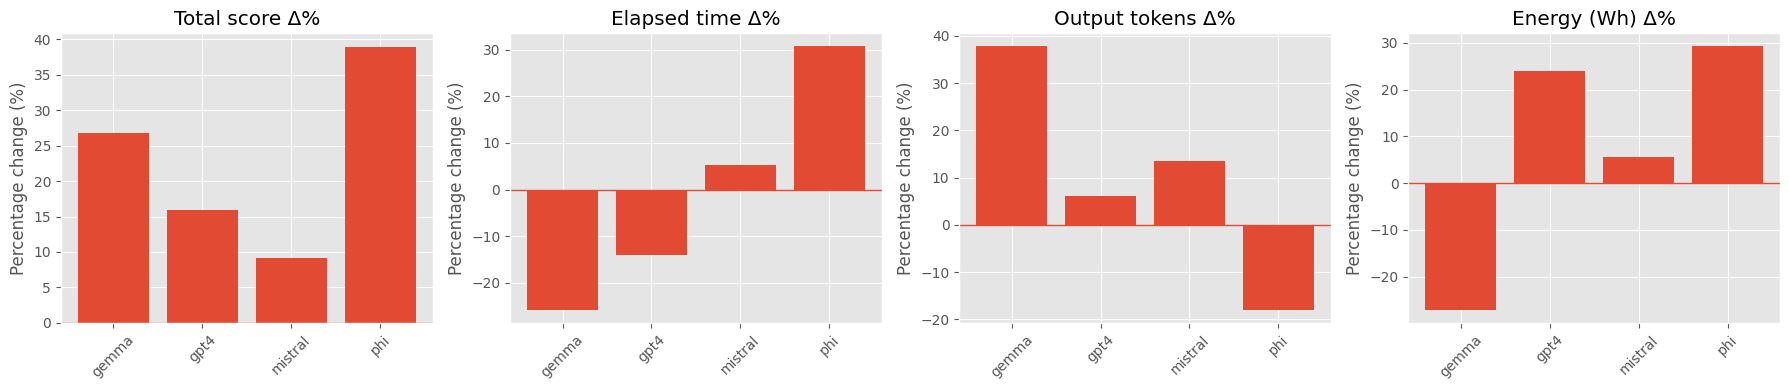

In [ ]:
# ---------- helper: percentage change (scalar) ----------
def pct(old, new):
    if pd.isna(old) or old == 0:
        return np.nan
    return (new - old) / old * 100.0

models = sorted(slm_comparison_df["model_name"].unique())

# (label, score_col, rouge_col)
TYPE_PAIRS = [
    ("style", "style_score", "style_rougeL"),
    ("logic", "logic_score", "logic_rougeL"),
    ("documentation", "documentation_score", "documentation_rougeL"),
    ("security", "security_score", "security_rougeL"),
    ("performance", "performance_score", "performance_rougeL"),
    ("other", "other_score", "other_rougeL"),
]

# ---------- build a DataFrame of percentage changes per model ----------
records = []

for model in models:
    row_zero = slm_comparison_df[
        (slm_comparison_df.model_name == model) &
        (slm_comparison_df.shot_type == "zero")
    ]
    row_few = slm_comparison_df[
        (slm_comparison_df.model_name == model) &
        (slm_comparison_df.shot_type == "few")
    ]
    if row_zero.empty or row_few.empty:
        continue

    z = row_zero.iloc[0]
    f = row_few.iloc[0]

    rec = {"model_name": model}

    # main metrics
    rec["total_score_pct"]     = pct(z["total_score"],     f["total_score"])
    rec["elapsed_s_pct"]       = pct(z["elapsed_s"],       f["elapsed_s"])
    rec["output_tokens_pct"]   = pct(z["output_tokens"],   f["output_tokens"])
    rec["energy_wh_pct"]       = pct(z["energy_wh"],       f["energy_wh"])

    # type-wise scores & rougeL
    for type_label, score_col, rouge_col in TYPE_PAIRS:
        rec[f"{type_label}_score_pct"]   = pct(z[score_col],   f[score_col])
        rec[f"{type_label}_rougeL_pct"]  = pct(z[rouge_col],   f[rouge_col])

    records.append(rec)

change_df = pd.DataFrame.from_records(records)
change_df.set_index("model_name", inplace=True)

# ======================================================
#   FIGURE 1: 1x4 — total, time, output, energy_wh
# ======================================================
fig1, axes = plt.subplots(1, 4, figsize=(18, 4), sharey=False)

x = np.arange(len(change_df.index))  # model positions
model_labels = change_df.index.tolist()

metrics1 = [
    ("total_score_pct",   "Total score Δ%"),
    ("elapsed_s_pct",     "Elapsed time Δ%"),
    ("output_tokens_pct", "Output tokens Δ%"),
    ("energy_wh_pct",     "Energy (Wh) Δ%"),
]

for ax, (col, title) in zip(axes, metrics1):
    vals = change_df[col].values
    ax.bar(x, vals)
    ax.axhline(0, linewidth=1)
    ax.set_title(title)
    ax.set_xticks(x)
    ax.set_xticklabels(model_labels, rotation=45)
    ax.set_ylabel("Percentage change (%)")

fig1.tight_layout()




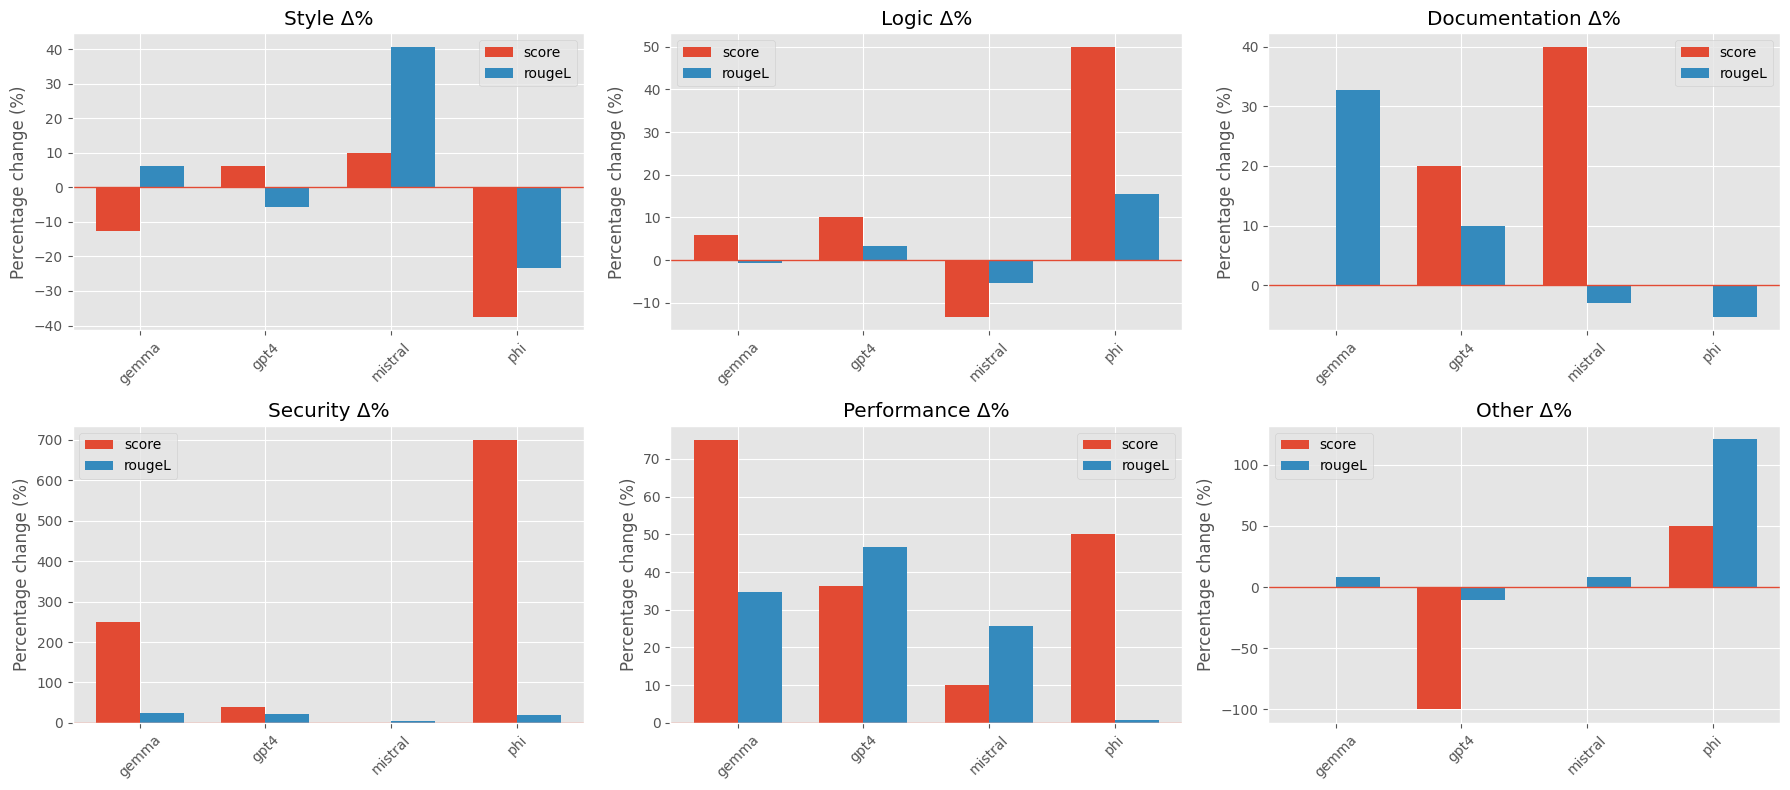

In [ ]:
# ======================================================
#   FIGURE 2: 2x3 — per type (score & rougeL)
# ======================================================
fig2, axes2 = plt.subplots(2, 3, figsize=(18, 8), sharey=False)
axes2 = axes2.flatten()

bar_width = 0.35
x = np.arange(len(change_df.index))

for ax, (type_label, _, _) in zip(axes2, TYPE_PAIRS):
    score_col  = f"{type_label}_score_pct"
    rouge_col  = f"{type_label}_rougeL_pct"

    score_vals = change_df[score_col].values
    rouge_vals = change_df[rouge_col].values

    ax.bar(x - bar_width/2, score_vals, width=bar_width, label="score")
    ax.bar(x + bar_width/2, rouge_vals, width=bar_width, label="rougeL")

    ax.axhline(0, linewidth=1)
    ax.set_title(f"{type_label.capitalize()} Δ%")
    ax.set_xticks(x)
    ax.set_xticklabels(model_labels, rotation=45)
    ax.set_ylabel("Percentage change (%)")
    ax.legend()

fig2.tight_layout()

plt.show()

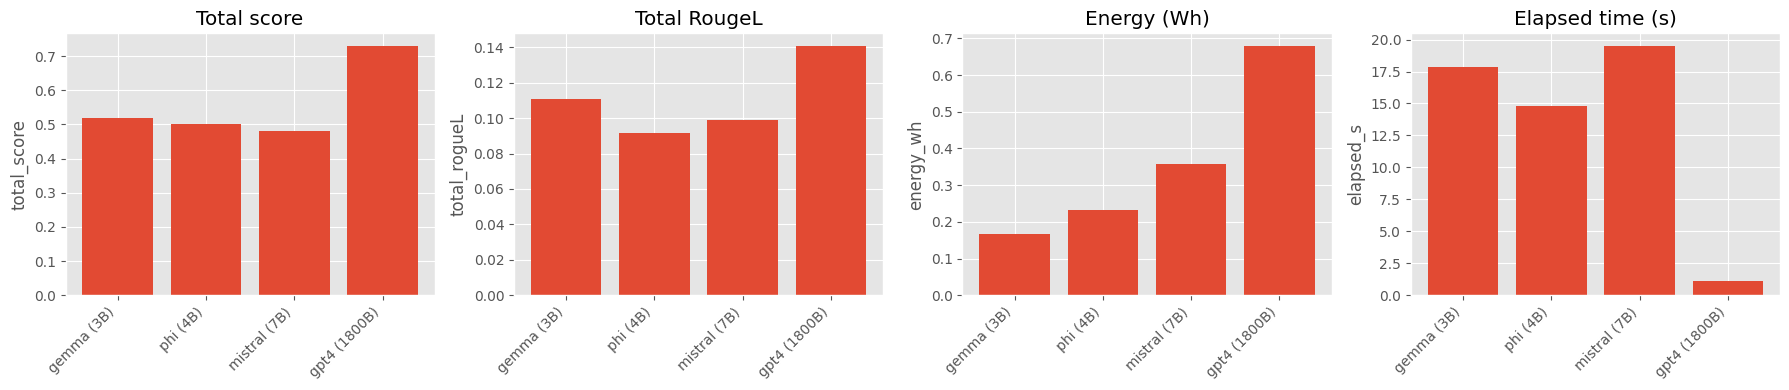

In [ ]:
# ---- filter to few-shot and sort by number of parameters ----
few_df = (
    slm_comparison_df[slm_comparison_df["shot_type"] == "few"]
    .copy()
    .sort_values("params_b")
)

x = np.arange(len(few_df))
x_labels = [
    f"{m} ({int(p)}B)" if float(p).is_integer() else f"{m} ({p}B)"
    for m, p in zip(few_df["model_name"], few_df["params_b"])
]

# ---- metrics to plot in 1x4 layout ----
metrics = [
    ("total_score",   "Total score"),
    ("total_rogueL",  "Total RougeL"),
    ("energy_wh",     "Energy (Wh)"),
    ("elapsed_s",     "Elapsed time (s)"),
]

fig, axes = plt.subplots(1, 4, figsize=(18, 4), sharey=False)

for ax, (col, title) in zip(axes, metrics):
    vals = few_df[col].values
    ax.bar(x, vals)
    ax.set_title(title)
    ax.set_xticks(x)
    ax.set_xticklabels(x_labels, rotation=45, ha="right")
    ax.set_ylabel(col)

fig.tight_layout()
plt.show()


In [ ]:
zero_df = (
    slm_comparison_df[slm_comparison_df["shot_type"] == "zero"]
    .copy()
    .sort_values("params_b")
)

metrics_cols = [
    "energy_wh",
    "elapsed_s",
    "total_rogueL",
    "total_score",


]

few_table = (
    few_df
    .set_index("model_name")[metrics_cols]
)

zero_table = (
    zero_df
    .set_index("model_name")[metrics_cols]
)

few_table


,energy_wh,elapsed_s,total_rogueL,total_score
model_name,,,,
gemma,0.167687,17.869231,0.110915,0.52
phi,0.231386,14.804070,0.091595,0.50
mistral,0.357145,19.512921,0.099072,0.48
gpt4,0.679794,1.125996,0.140810,0.73


In [ ]:
aggregated_table = pd.concat(
    {
        "zero-shot": zero_table,
        "few-shot": few_table,
    },
    axis=1
)

# reorder columns to: Metric → Shot
aggregated_table = (
    aggregated_table
    .swaplevel(axis=1)
    .sort_index(axis=1)
)

aggregated_table


elapsed_s            energy_wh           total_rogueL            \
             few-shot  zero-shot  few-shot zero-shot     few-shot zero-shot   
model_name                                                                    
gemma       17.869231  24.068394  0.167687  0.230015     0.110915  0.096936   
phi         14.804070  11.328420  0.231386  0.179084     0.091595  0.087943   
mistral     19.512921  18.522571  0.357145  0.338383     0.099072  0.089629   
gpt4         1.125996   1.310640  0.679794  0.548700     0.140810  0.129032   

           total_score            
              few-shot zero-shot  
model_name                        
gemma             0.52      0.41  
phi               0.50      0.36  
mistral           0.48      0.44  
gpt4              0.73      0.63

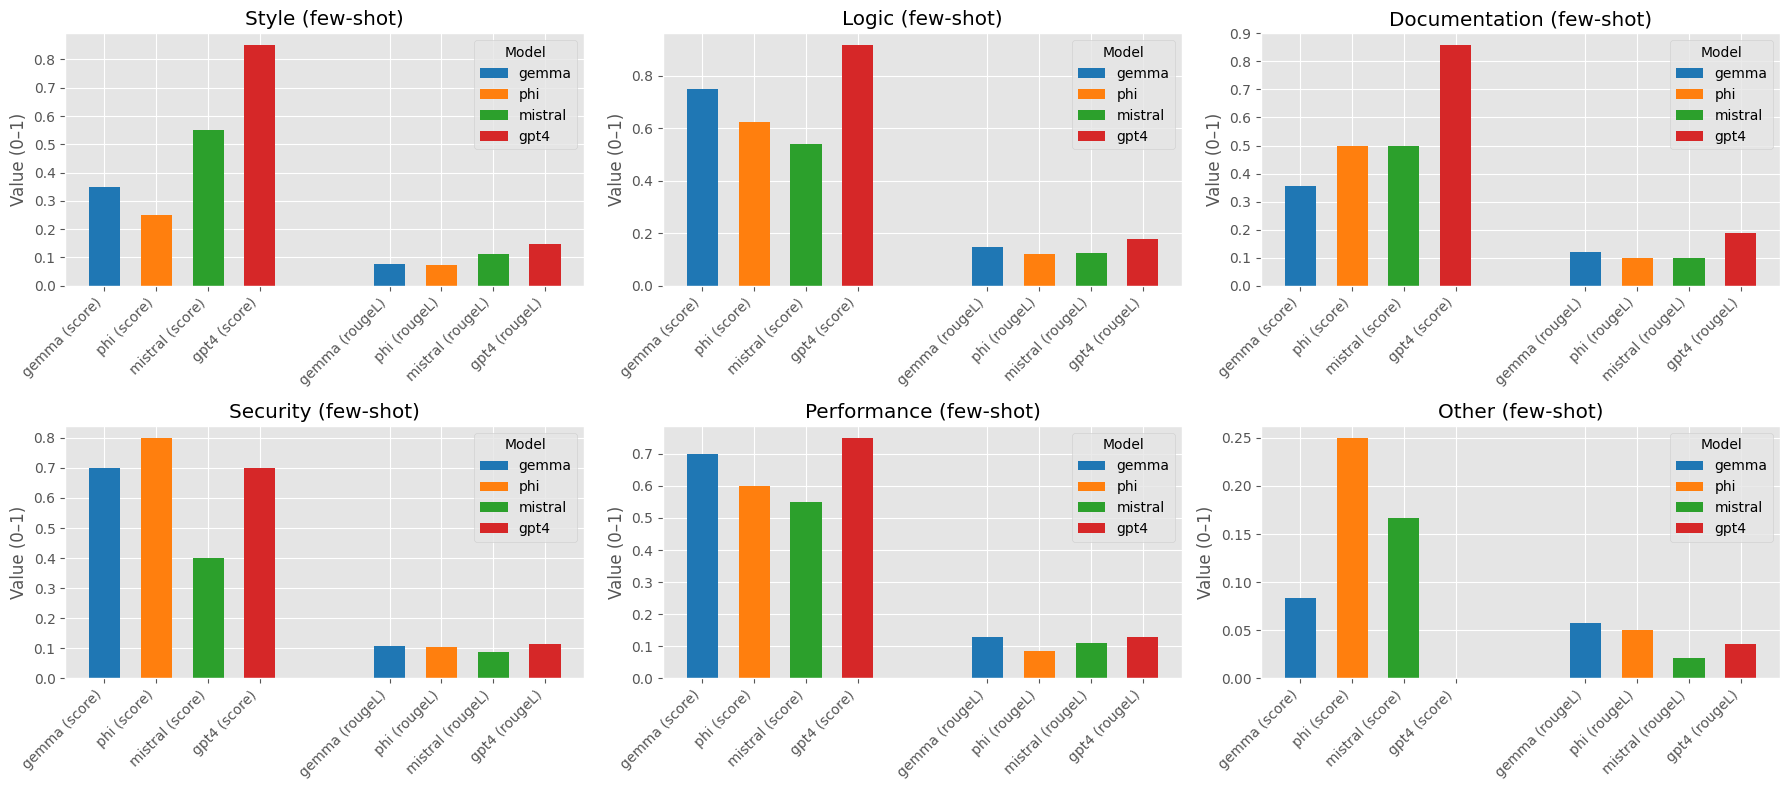

In [ ]:
TYPE_PAIRS = [
    ("style", "style_score", "style_rougeL"),
    ("logic", "logic_score", "logic_rougeL"),
    ("documentation", "documentation_score", "documentation_rougeL"),
    ("security", "security_score", "security_rougeL"),
    ("performance", "performance_score", "performance_rougeL"),
    ("other", "other_score", "other_rougeL"),
]

# ---- few-shot models sorted by params ----
few_df = (
    slm_comparison_df[slm_comparison_df["shot_type"] == "few"]
    .copy()
    .sort_values("params_b")
)

models = few_df["model_name"].tolist()
params = few_df["params_b"].tolist()

# consistent colors per model
model_colors = {
    "gemma": "tab:blue",
    "phi": "tab:orange",
    "mistral": "tab:green",
    "gpt4": "tab:red",
}

# x positions: two groups with a gap between them
n_models = len(models)
group_gap = 1.5  # space between score-group and rouge-group

score_x = np.arange(n_models)                      # 0,1,2,3
rouge_x = score_x + n_models + group_gap           # 0+4+gap, 1+4+gap, ...

fig, axes = plt.subplots(2, 3, figsize=(18, 8))
axes = axes.flatten()

bar_width = 0.6  # thinner bars

for ax, (type_label, score_col, rouge_col) in zip(axes, TYPE_PAIRS):
    # values
    score_vals = [
        few_df.loc[few_df["model_name"] == m, score_col].iloc[0]
        for m in models
    ]
    rouge_vals = [
        few_df.loc[few_df["model_name"] == m, rouge_col].iloc[0]
        for m in models
    ]

    # legend control so each model appears once
    used_labels = set()

    # --- score group (left) ---
    for i, m in enumerate(models):
        color = model_colors.get(m, None)
        label = m if m not in used_labels else "_nolegend_"
        ax.bar(score_x[i], score_vals[i],
               width=bar_width, color=color, label=label)
        used_labels.add(m)

    # --- rouge group (right) ---
    for i, m in enumerate(models):
        color = model_colors.get(m, None)
        # same model color, no extra legend entry
        ax.bar(rouge_x[i], rouge_vals[i],
               width=bar_width, color=color)

    # x tick labels: first group = score, second = rougeL
    xticks = np.concatenate([score_x, rouge_x])
    xlabels = (
        [f"{m} (score)" for m in models] +
        [f"{m} (rougeL)" for m in models]
    )

    ax.set_xticks(xticks)
    ax.set_xticklabels(xlabels, rotation=45, ha="right")

    ax.set_title(f"{type_label.capitalize()} (few-shot)")
    ax.set_ylabel("Value (0–1)")
    ax.legend(title="Model")

fig.tight_layout()
plt.show()
